# Libraries

In [1]:
import gc
import math
import datetime
import sys
sys.path.append('../input/timmpytorchimagemodels/pytorch-image-models-master') # add library
from timm import create_model
from fastai.vision.all import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

In [2]:
set_seed(2999, reproducible=True)

# Data

In [3]:
# dataset path
dataset_path = Path('../input/petfinder-pawpularity-score/')

In [4]:
df_train = pd.read_csv(dataset_path/'train.csv')
df_train.head(10)

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,0,0,0,63
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,0,0,0,42
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,1,0,0,28
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,0,0,0,15
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,0,0,0,72
5,001dd4f6fafb890610b1635f967ea081,0,0,1,0,0,0,0,0,0,0,0,1,74
6,0023b8a3abc93c712edd6120867deb53,0,1,1,1,0,0,0,0,1,1,0,0,22
7,0031d6a9ef7340f898c3e05f92c7bb04,0,1,1,0,0,0,1,1,0,0,1,0,35
8,0042bc5bada6d1cf8951f8f9f0d399fa,0,1,1,1,0,0,0,0,0,0,0,0,53
9,0049cb81313c94fa007286e9039af910,0,1,1,1,0,0,0,0,0,0,0,0,21


In [5]:
df_train['path'] = df_train['Id'].map(lambda x:str(dataset_path/'train'/x)+'.jpg')
df_train = df_train.drop(columns=['Id'])
# shuffle dataframe
df_train = df_train.sample(frac=1).reset_index(drop=True) 
df_train.head(10)

,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,path
0,0,1,1,1,0,1,0,0,0,0,0,0,27,../input/petfinder-pawpularity-score/train/fa123435b35cf07a6c53f8d5a5c36f6c.jpg
1,0,1,1,1,0,0,0,0,0,0,0,0,30,../input/petfinder-pawpularity-score/train/d7d222be164177b8a1033fb51a5d762f.jpg
2,0,1,1,1,0,0,1,0,0,0,0,0,26,../input/petfinder-pawpularity-score/train/62caf65e5c6ae1d881d1bb986b609011.jpg
3,0,1,1,1,0,0,0,0,0,0,0,0,24,../input/petfinder-pawpularity-score/train/c2243c99e0a96d5e0dfbb9b00e922bed.jpg
4,0,1,1,1,0,0,0,0,0,0,0,0,75,../input/petfinder-pawpularity-score/train/ddcffbbc1a816adbbe38339f19c6b5f9.jpg
5,0,1,1,0,0,0,1,0,0,0,0,0,35,../input/petfinder-pawpularity-score/train/2ccc26b6ecc9c8ff4153761f6a03f58e.jpg
6,0,1,1,1,0,0,0,0,0,0,0,0,26,../input/petfinder-pawpularity-score/train/92189fde724e45c04af7235e29970040.jpg
7,0,1,1,1,0,0,0,0,1,1,0,0,34,../input/petfinder-pawpularity-score/train/027a909fd3bc802f80646e92f8fdcd50.jpg
8,0,1,0,1,0,0,0,0,0,0,0,0,29,../input/petfinder-pawpularity-score/train/56f43f28d69c193544627d7bed5c8f81.jpg
9,0,1,1,1,0,0,0,0,0,0,0,0,36,../input/petfinder-pawpularity-score/train/b9cf47f8b3b5a0855bb3293b138776e5.jpg


In [6]:
df_train.shape

(9912, 14)

Mean:  38.03904358353511
Median:  33.0
Std:  20.591990105774542


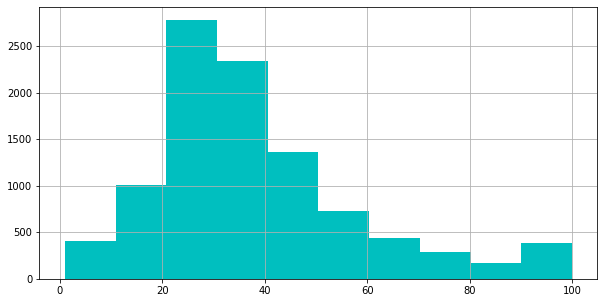

In [7]:
df_train['Pawpularity'].hist(figsize = (10, 5), color='c')
print("Mean: ", df_train['Pawpularity'].mean())
print("Median: ", df_train['Pawpularity'].median())
print("Std: ", df_train['Pawpularity'].std())

In [8]:
len(df_train['Pawpularity'].unique())

100

**Note that the Pawpularity score is an integer, so in addition to being a regression problem, it could also be treated as a 100-class classification problem. Alternatively, it can be treated as a binary classification problem if the Pawpularity Score is normalized between 0 and 1:**

In [9]:
Pawpularity_max = 100

In [10]:
# normalize data
df_train['norm_score'] = df_train['Pawpularity'] / Pawpularity_max
df_train['norm_score']

0       0.27
1       0.30
2       0.26
3       0.24
4       0.75
        ... 
9907    0.97
9908    0.24
9909    0.34
9910    0.56
9911    0.49
Name: norm_score, Length: 9912, dtype: float64

In [11]:
im = Image.open(df_train["path"][1])
width, height = im.size
print(width, height)

467 960


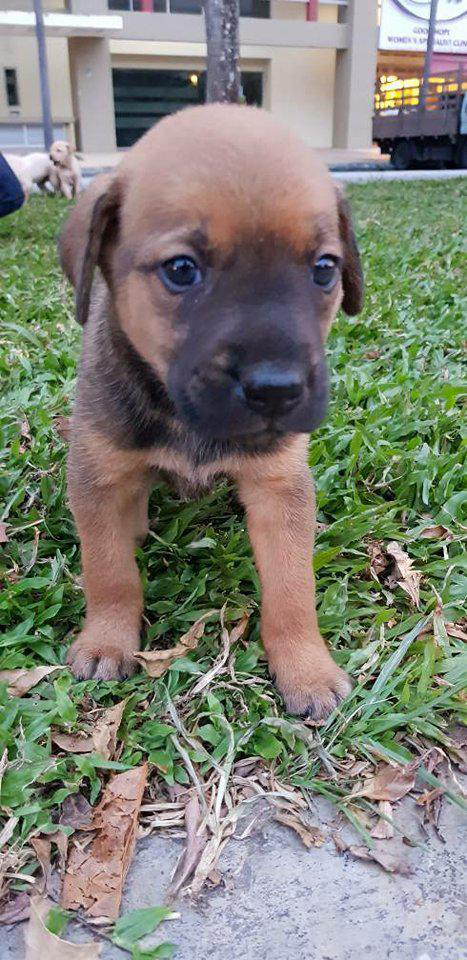

In [12]:
im

# Swin Transform

In [13]:
if not os.path.exists('/root/.cache/torch/hub/checkpoints/'):
    os.makedirs('/root/.cache/torch/hub/checkpoints/')
    
!cp '../input/swin-transformer/swin_large_patch4_window7_224_22kto1k.pth' '/root/.cache/torch/hub/checkpoints/swin_large_patch4_window7_224_22kto1k.pth'

In [14]:
# set seed
seed = 999
set_seed(seed, reproducible=True)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True

# Optimal Number of Bins

In [15]:
#S turges' rule
num_bins = int(np.floor(1+(3.3)*(np.log2(len(df_train)))))
num_bins

44

<AxesSubplot:>

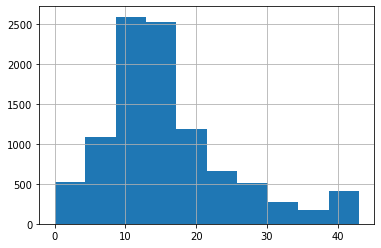

In [16]:
df_train['bins'] = pd.cut(df_train['norm_score'], bins=num_bins, labels=False)
df_train['bins'].hist()

In [17]:
N_FOLDS = 7

df_train['fold'] = -1

strat_kfold = StratifiedKFold(n_splits=N_FOLDS, random_state=seed, shuffle=True)

for i, (_, train_index) in enumerate(strat_kfold.split(df_train.index, df_train['bins'])):
    df_train.iloc[train_index, -1] = i
    
df_train['fold'] = df_train['fold'].astype('int')

<AxesSubplot:>

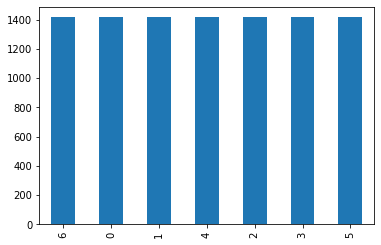

In [18]:
df_train.fold.value_counts().plot.bar()

In [19]:
df_train[df_train['fold']==0].head()

,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,path,norm_score,bins,fold
1,0,1,1,1,0,0,0,0,0,0,0,0,30,../input/petfinder-pawpularity-score/train/d7d222be164177b8a1033fb51a5d762f.jpg,0.30,12,0
4,0,1,1,1,0,0,0,0,0,0,0,0,75,../input/petfinder-pawpularity-score/train/ddcffbbc1a816adbbe38339f19c6b5f9.jpg,0.75,32,0
5,0,1,1,0,0,0,1,0,0,0,0,0,35,../input/petfinder-pawpularity-score/train/2ccc26b6ecc9c8ff4153761f6a03f58e.jpg,0.35,15,0
7,0,1,1,1,0,0,0,0,1,1,0,0,34,../input/petfinder-pawpularity-score/train/027a909fd3bc802f80646e92f8fdcd50.jpg,0.34,14,0
19,0,1,1,0,0,0,1,0,1,0,0,0,40,../input/petfinder-pawpularity-score/train/b42907d9b673a42048bd2869b36bfe53.jpg,0.40,17,0


In [20]:
df_train[df_train['fold']==0]['bins'].value_counts()

11    134
15    100
12     89
13     87
10     77
14     70
9      70
7      60
17     54
20     53
8      51
16     51
18     49
43     44
19     36
23     35
21     30
27     25
0      24
6      24
22     23
4      22
5      20
25     18
24     18
31     16
26     14
28     13
3      11
29     10
1      10
30      9
35      9
32      8
33      8
2       7
34      7
38      6
36      6
40      6
37      4
42      3
41      3
39      2
Name: bins, dtype: int64

In [21]:
df_train[df_train['fold']==1]['bins'].value_counts()

11    134
15    100
12     89
13     86
10     77
14     70
9      70
7      60
20     53
17     53
16     52
8      51
18     49
43     43
19     36
23     35
21     30
27     25
0      24
6      23
4      22
22     22
5      21
25     19
24     18
31     16
26     15
28     14
3      11
29     10
1      10
30      9
2       8
35      8
32      8
33      8
34      7
38      6
40      6
36      6
37      4
41      3
39      3
42      2
Name: bins, dtype: int64

In [22]:
def rmse(input_, target):
    res = torch.sqrt(F.mse_loss(Pawpularity_max*F.sigmoid(input_.flatten()), Pawpularity_max*target))
    return res

# Load data

In [23]:
fraction = 0.1 # val data fraction
valid_col = 'is_valid'
fn_col = "path"
label_col = 'norm_score'
batch_size = 8
num_workers = 8 # for GPU parallel computing
item_tfms = 224
batch_tfms = setup_aug_tfms([Brightness(), Contrast(), Hue(), Saturation()])
# batch_tfms = setup_aug_tfms([Rotate(), Zoom(), Brightness(), Contrast()])

In [24]:
def get_data(fold):
    df_train_f = df_train.copy()
    # add is_valid for validation fold
    df_train_f['is_valid'] = (df_train_f['fold'] == fold)
    dls = ImageDataLoaders.from_df(
                               df_train_f, #pass in train DataFrame
                               valid_pct=fraction, # train-validation random split
                               valid_col=valid_col,
                               seed=seed, #seed
                               fn_col=fn_col, #filename/path is in the second column of the DataFrame
                               label_col=label_col, #label is in the first column of the DataFrame
                               y_block=RegressionBlock, #The type of target
                               bs=batch_size, #pass in batch size
                               num_workers=num_workers,
                               item_tfms=Resize(224), #pass in item_tfms
                               batch_tfms=batch_tfms #pass in batch_tfms
                               )
    return dls

In [25]:
# valid Kfolder size
the_data = get_data(0)
assert (len(the_data.train) + len(the_data.valid)) == (len(df_train)//batch_size)

# Model

In [26]:
def get_learner(fold_num):
    data = get_data(fold_num)
    model = create_model('swin_large_patch4_window7_224', pretrained=True, num_classes=data.c)
    learn = Learner(data, 
                    model, 
                    loss_func=BCEWithLogitsLossFlat(), 
                    metrics=rmse).to_fp16()
    
    return learn

In [27]:
df_test = pd.read_csv(dataset_path/'test.csv')
df_test.head()

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,4128bae22183829d2b5fea10effdb0c3,1,0,1,0,0,1,1,0,0,1,0,1
1,43a2262d7738e3d420d453815151079e,0,1,0,0,0,0,1,1,0,0,0,0
2,4e429cead1848a298432a0acad014c9d,0,0,0,1,0,1,1,1,0,1,1,1
3,80bc3ccafcc51b66303c2c263aa38486,1,0,1,0,0,0,0,0,0,0,1,0
4,8f49844c382931444e68dffbe20228f4,1,1,1,0,1,1,0,1,0,1,1,0


In [28]:
df_test['Pawpularity'] = [1]*len(df_test)
df_test['path'] = df_test['Id'].map(lambda x:str(dataset_path/'test'/x)+'.jpg')
df_test = df_test.drop(columns=['Id'])
df_test['norm_score'] = df_test['Pawpularity']/100

SuggestedLRs(valley=4.256162355886772e-05)

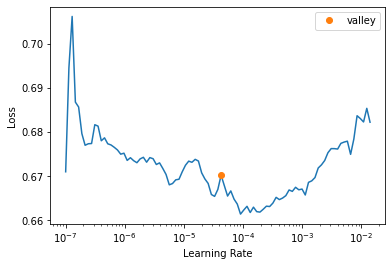

In [29]:
get_learner(fold_num=0).lr_find(end_lr=3e-2)

Fold 0 results


epoch,train_loss,valid_loss,rmse,time
0,0.643291,0.645076,17.418671,08:17
1,0.642339,0.642979,16.912695,08:18
2,0.636257,0.642331,16.919899,08:18
3,0.623331,0.644252,16.943672,08:19
4,0.613556,0.645781,17.011297,08:18


/opt/conda/lib/python3.7/site-packages/torch/nn/functional.py:1805: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Better model found at epoch 0 with valid_loss value: 0.6450755000114441.
Better model found at epoch 1 with valid_loss value: 0.6429791450500488.
Better model found at epoch 2 with valid_loss value: 0.6423311233520508.
No improvement since epoch 1: early stopping


Fold 1 results


...

Better model found at epoch 0 with valid_loss value: 0.6449798345565796.
Better model found at epoch 1 with valid_loss value: 0.641543447971344.
Better model found at epoch 2 with valid_loss value: 0.6400085091590881.
No improvement since epoch 2: early stopping


Fold 6 results


epoch,train_loss,valid_loss,rmse,time
0,0.641138,0.647199,17.501120,08:18
1,0.642871,0.649098,18.083582,08:18
2,0.624334,0.640699,16.737337,08:19
3,0.620310,0.642668,17.028461,08:18
4,0.620121,0.643868,17.034914,08:18
5,0.609383,0.645949,17.288437,08:18


/opt/conda/lib/python3.7/site-packages/torch/nn/functional.py:1805: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Better model found at epoch 0 with valid_loss value: 0.6471994519233704.
Better model found at epoch 2 with valid_loss value: 0.6406985521316528.
No improvement since epoch 2: early stopping


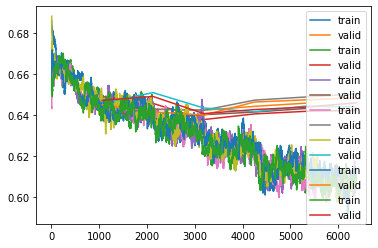

In [30]:
all_preds = []

for i in range(N_FOLDS):

    print(f'Fold {i} results')

    learn = get_learner(fold_num=i)
    learn.fit_one_cycle(6, 2e-5, cbs=[SaveModelCallback(), 
                                      EarlyStoppingCallback(monitor='rmse', 
                                                            comp=np.less, 
                                                            patience=3)
                                     ]) 
    learn.recorder.plot_loss()


    dls = ImageDataLoaders.from_df(df_train, #pass in train DataFrame
                               valid_pct=fraction, 
                               seed=seed, #seed
                               fn_col=fn_col, #filename/path is in the second column of the DataFrame
                               label_col=label_col, #label is in the first column of the DataFrame
                               y_block=RegressionBlock, #The type of target
                               bs=batch_size, #pass in batch size
                               num_workers=num_workers,
                               item_tfms=Resize(224), #pass in item_tfms
                               batch_tfms=setup_aug_tfms(batch_tfms)
                               ) 

    test_dl = dls.test_dl(df_test)

    preds, _ = learn.tta(dl=test_dl, n=5, beta=0)

    all_preds.append(preds)

    learn = learn.to_fp32()
    
    now = datetime.now()  
    # learn.export(f'model_fold_{i}_' + now.strftime("%Y-%m-%d--%H-%M-%S") + '.pkl')
    learn.save(f'model_fold_{i}_' + now.strftime("%Y-%m-%d--%H-%M-%S") + '.pth')

    del learn, dls, test_dl
    torch.cuda.empty_cache()
    gc.collect()

In [31]:
all_preds

[tensor([[0.4930],
         [0.5050],
         [0.4970],
         [0.5005],
         [0.5118],
         [0.5117],
         [0.4965],
         [0.5009]]),
 tensor([[0.3523],
         [0.3746],
         [0.3573],
         [0.3779],
         [0.3572],
         [0.3604],
         [0.3570],
         [0.3632]]),
 tensor([[0.4629],
         [0.4706],
         [0.4612],
         [0.4723],
         [0.4647],
         [0.4672],
         [0.4680],
         [0.4710]]),
 tensor([[0.3894],
         [0.4001],
         [0.3842],
         [0.4020],
         [0.3897],
         [0.4005],
         [0.3947],
         [0.3853]]),
 tensor([[0.3862],
         [0.3902],
         [0.3884],
         [0.3966],
         [0.3839],
         [0.3958],
         [0.3896],
         [0.3888]]),
 tensor([[0.4114],
         [0.4091],
         [0.4026],
         [0.4216],
         [0.3953],
         [0.4157],
         [0.4098],
         [0.4239]]),
 tensor([[0.4022],
         [0.4149],
         [0.4024],
         [0.4161],


In [32]:
np.mean(np.stack(all_preds*100))

0.41897792

In [33]:
sample_df = pd.read_csv(dataset_path/'sample_submission.csv')
preds = np.mean(np.stack(all_preds), axis=0)
sample_df['Pawpularity'] = preds*100
sample_df.to_csv('submission.csv',index=False)

In [34]:
pd.read_csv('submission.csv').head()

,Id,Pawpularity
0,4128bae22183829d2b5fea10effdb0c3,41.390846
1,43a2262d7738e3d420d453815151079e,42.349808
2,4e429cead1848a298432a0acad014c9d,41.329525
3,80bc3ccafcc51b66303c2c263aa38486,42.671608
4,8f49844c382931444e68dffbe20228f4,41.378574
